## Post-processing Interferograms from ALOS-2

```bash
cd ~/data/2023TurkeyEQ/ALOS2_A184_20220905_20230220
screen -S ALOS2_A184 -L
load_insar
alos2App.py alos2App.xml --steps --end=ion_unwrap
```

In [2]:
%matplotlib inline
import os
import numpy as np
import platform
from PIL import Image, ImageDraw
from matplotlib import pyplot as plt, ticker
from mintpy.utils import ptime, readfile, writefile, plot as pp, utils as ut, isce_utils
from mintpy.cli import view, subset, prep_isce, mask, geocode
from skimage.transform import resize
plt.rcParams.update({'font.size': 12})
cmy = pp.ColormapExt('cmy').colormap

dname = 'ALOS2_D041';  
proj_dir = f'/penguin/eedy/25EQ_myanmar'
work_dir = f'/penguin/eedy/25EQ_myanmar'

# input/output files
gmt_lonlat_file = os.path.join(proj_dir, f'simple_rupture_trace.lonlat')
date1 = 250216
date2 = 250330
fbase = f'{date1}-{date2}_5rlks_28alks'

int_file = f'filt_{fbase}.int'
cor_file = f'filt_{fbase}.cor'
unw_file = f'filt_{fbase}.unw'
lat_file = f'{fbase}.lat'
lon_file = f'{fbase}.lon'
wbd_file = f'{fbase}.wbd'
msk_file = f'{fbase}.msk'

dem_file = os.path.join(proj_dir, 'DEM/elevation_mli.dem')
flt_file = os.path.join(proj_dir, 'simple_rupture_trace.lonlat')

In [3]:
def generate_mask4earthquake_rupture(gmt_lonlat_file, int_file, msk_file, lookup_file, rupture_width=20):
    """Generate mask for earthquake ruptures, to facilitae the phase unwrapping of co-seismic deformation.

    Parameters: rupture_files - list(str), path to the text file of rupture traces in GMT lonlat format
                int_file      - str, path to the interferogram
                msk_file      - str, path to the output mask file
                lookup_file   - list(str), path to the lookup table files, e.g.:
                                'geometryRadar.h5', or 
                                ['lat.rdr', 'lon.rdr']
                rupture_width - int, surface rupture width in pixels
    Returns:    msk_file      - str, path to the output mask file
    """
    work_dir = os.path.dirname(os.path.abspath(int_file))
    # go to work directory
    os.chdir(work_dir)
    print('Go to directory:', work_dir)

    # read EQ rupture trace files
    faults_lola = readfile.read_gmt_lonlat_file(gmt_lonlat_file, min_dist=0)

    # translate lat/lon into local X/Y coordinates
    atr = readfile.read_attribute(int_file)
    coord = ut.coordinate(atr, lookup_file=lookup_file)
    faults_xy = []
    num_fault = faults_lola[0].shape[0]
    print('translating lat/lon into local X/Y coordiantes...')
    prog_bar = ptime.progressBar(maxValue=num_fault)
    for i, fault_lola in enumerate(faults_lola[0]):
        prog_bar.update(i+1, suffix=f'fault {i+1}/{num_fault} ({fault_lola.shape[0]} points)')
        # translate point-by-point to keep faults with partial points outside of the coverage
        fault_xy = []
        y, x = coord.geo2radar(fault_lola[1], fault_lola[0])[:2]
        fault_xy.append((x, y))
        if fault_xy:
            faults_xy.append(fault_xy)
    prog_bar.close()
    print(faults_xy)

    # rasterize
    # link: https://pillow.readthedocs.io/en/stable/reference/ImageDraw.html
    print(f'rasterize local X/Y coordiantes with a width of {rupture_width} pixels')
    length, width = int(atr['LENGTH']), int(atr['WIDTH'])
    img = Image.new('L', (int(width), int(length)), 1)
    #for i, fault_xy in enumerate(faults_xy):
        #ImageDraw.Draw(img).line(fault_xy, fill=0, width=rupture_width, joint='curve')
    # 创建一个新的图像，初始值为 1
    draw = ImageDraw.Draw(img)
    # 处理点集，确保绘制连续的曲线
    points = [point[0] for point in faults_xy]
    draw.line(points, fill=0, width=rupture_width, joint='curve')
    msk = np.array(img, dtype=np.bool_)

    # write to file
    meta = dict(atr)
    meta['FILE_TYPE'] = '.msk'
    meta['DATA_TYPE'] = 'bool'
    meta['BANDS'] = 1
    meta['HEIGHT'] = 697951.8596326977
    writefile.write(msk, out_file=msk_file, metadata=meta, ref_file=cor_file)
    print(f'write mask to file: {msk_file}')

    # plot
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=[12, 6])
    ax = axs[0]
    for i, fault in enumerate(faults_lola):
        ax.plot(fault[:,0], fault[:,1], label=i+1)
    ax.set_aspect('equal')
    ax.legend(ncol=3)
    ax = axs[1]
    im = ax.imshow(msk, cmap='gray', interpolation='nearest')
    pp.auto_flip_direction(atr, ax=ax)
    fig.colorbar(im, ax=ax, shrink=0.5)
    plt.show()

    return msk_file

print('warm up utils functioins.')

warm up utils functioins.


## 1. Ionospheric correction

Re-run phase unwrapping for ion estimation, by masking out the near-field ruptures, to avoid PU errors.

Go to directory: /penguin/eedy/25EQ_myanmar/ion/ion_cal
Go to directory: /penguin/eedy/25EQ_myanmar/ALOS2_D041/ion/ion_cal
translating lat/lon into local X/Y coordiantes...
[==================================================] fault 36/36 (2 points)    5s /     0s 
[[(252, 473)], [(250, 486)], [(249, 508)], [(244, 549)], [(242, 563)], [(240, 580)], [(240, 580)], [(239, 589)], [(237, 599)], [(236, 609)], [(234, 624)], [(231, 657)], [(229, 667)], [(227, 681)], [(221, 721)], [(218, 746)], [(213, 779)], [(209, 807)], [(202, 848)], [(194, 893)], [(186, 937)], [(181, 964)], [(181, 966)], [(180, 974)], [(179, 982)], [(178, 983)], [(176, 997)], [(173, 1010)], [(172, 1016)], [(169, 1031)], [(166, 1046)], [(148, 1141)], [(147, 1146)], [(139, 1184)], [(127, 1247)], [(124, 1263)]]
rasterize local X/Y coordiantes with a width of 5 pixels
write file: /penguin/eedy/25EQ_myanmar/ALOS2_D041/ion/ion_cal/msk_80rlks_224alks.msk
write file: /penguin/eedy/25EQ_myanmar/ALOS2_D041/ion/ion_cal/msk_80rlks_224alk

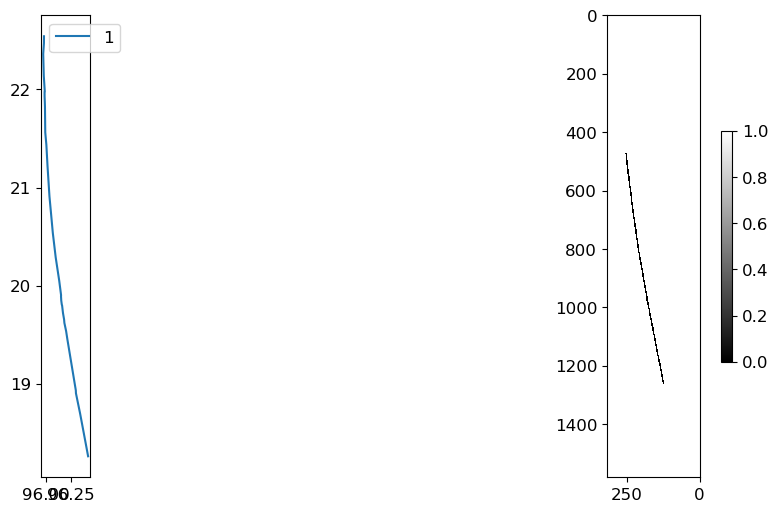

'/penguin/eedy/25EQ_myanmar/ALOS2_D041/ion/ion_cal/msk_80rlks_224alks.msk'

In [3]:
# work dir
os.chdir(os.path.join(proj_dir, dname, 'ion/ion_cal'))
print('Go to directory:', os.path.join(proj_dir, 'ion/ion_cal'))

# generate mask for EQ ruptures
mli_str = '80rlks_224alks'
rupture_width = 5
ion_lookup_file = [f'lat_{mli_str}.lat', f'lon_{mli_str}.lon']
ion_msk_file = os.path.abspath(f'msk_{mli_str}.msk')
ion_int_file = os.path.abspath(f'lower_{mli_str}.int')

#prep_isce.main(f'-f {ion_int_file} -m ../../250216.track.xml -g ./  -b ../../baselines'.split())
generate_mask4earthquake_rupture(gmt_lonlat_file, int_file=ion_int_file, msk_file=ion_msk_file, lookup_file=ion_lookup_file, rupture_width=rupture_width)

In [ ]:
os.chdir(os.path.join(proj_dir, dname, 'ion/ion_cal'))
print(f'cd {os.path.join(proj_dir, dname, "ion/ion_cal")}')
print(f'screen -S {dname.split("_")[1]}_UNW -L\nload_insar')

for suffix in ['lower', 'upper']:
    ion_int_file = f'{suffix}_{mli_str}.int'
    ion_cor_file = f'{suffix}_{mli_str}.phsig'
    ion_unw_file = f'{suffix}_{mli_str}.unw'
    # prepare metadata
    #prep_isce.main(f'-f {os.path.abspath(ion_int_file)} -m ../../2*.track.xml -g ./'.split())
    # unwrap cmd
    cmd = f'unwrap.py -i {ion_int_file} -c {ion_cor_file} -o {ion_unw_file} --mask {ion_msk_file} '
    cmd += '--max-comp 20  --init-only --init-method MCF --cost-mode DEFO '
    print(cmd)
    os.system(cmd)

# re-run alos2App
print('\n'+'-'*50)
os.chdir(os.path.join(proj_dir, dname))
print(f'cd {os.path.join(proj_dir, dname)}')
cmd = 'alos2App.py alos2App.xml --steps --start=ion_filt --end=filt'
print(cmd)
os.system(cmd)

## 3. Phase unwrapping

### 3.1 Subset (no use)

In [11]:
# go to sub directory
os.chdir(os.path.join(proj_dir, dname,f'insar'))
#print('Go to directory:', proj_dir)

# prepare meta and cor file
prep_isce.main(f'-f {int_file} -m ../250216.track.xml -g ../'.split())
isce_utils.estimate_coherence(int_file, cor_file)

['../data.rsc'] exists and is newer than ['../250216.track.xml'] --> skip.
preparing RSC file for geometry files
preparing RSC file for: filt_250216-250330_5rlks_28alks.int
Done.
GDAL open (R): filt_250216-250330_5rlks_28alks.int.vrt
API open (WR): filt_250216-250330_5rlks_28alks.cor

 << PS filtering >>


 interferogram width:  5101  number of lines/patch:  3700
 start line:        1  number of lines:   12658
 start sample:      1  end sample:         5101

 azimuth buffer size:                             3700
 overlap between azimuth patches:                  200
 total overlap between azimuth patches:            264
 offset in overlap region for phase  bootstrap:    132
 lines to increment for the next patch:           3436
 number of patches:                                  4

 PATCH:   1   starting line:     0    lines read: 3700
 starting output line:    1   ending output line: 3568

 PATCH:   2   starting line:  3436    lines read: 3700
 starting output line:  133   ending out

### 3.2 Generate mask for EQ ruptures

+ exclude fault rupture traces
+ [skip] exclude water body. Skipped as water body is not large & not in the near field -> not a problem for PU.
+ [skip] exclude very low coherent pixels. Skipped to let SNAPHU handle it.

Go to directory: /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar
translating lat/lon into local X/Y coordiantes...
[==================================================] fault 36/36 (2 points)  218s /     6s 
[[(4043, 3794)], [(4021, 3899)], [(3998, 4067)], [(3917, 4401)], [(3885, 4511)], [(3847, 4643)], [(3850, 4647)], [(3835, 4717)], [(3814, 4799)], [(3793, 4880)], [(3765, 5002)], [(3705, 5265)], [(3682, 5339)], [(3646, 5453)], [(3557, 5775)], [(3500, 5974)], [(3424, 6236)], [(3352, 6465)], [(3249, 6787)], [(3121, 7154)], [(2989, 7503)], [(2914, 7720)], [(2912, 7732)], [(2895, 7800)], [(2873, 7861)], [(2865, 7875)], [(2827, 7987)], [(2789, 8084)], [(2774, 8134)], [(2720, 8255)], [(2675, 8374)], [(2381, 9134)], [(2371, 9177)], [(2242, 9478)], [(2041, 9979)], [(1991, 10108)]]
rasterize local X/Y coordiantes with a width of 20 pixels
write file: 250216-250330_5rlks_28alks.msk
write file: 250216-250330_5rlks_28alks.msk.rsc
write mask to file: 250216-250330_5rlks_28alks.msk
DESCENDING orbit -> 

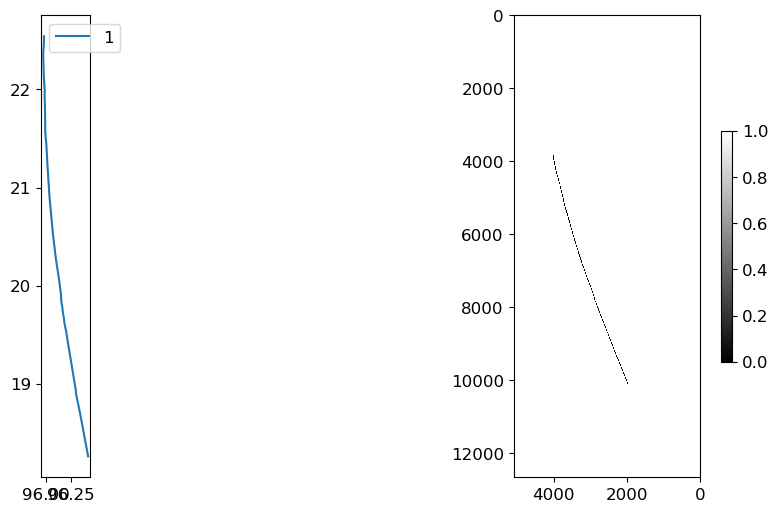

'250216-250330_5rlks_28alks.msk'

In [12]:
gmt_lonlat_file = os.path.join(proj_dir, f'simple_rupture_trace.lonlat')
generate_mask4earthquake_rupture(gmt_lonlat_file, int_file=int_file, msk_file=msk_file, lookup_file=[lat_file, lon_file])

### 3.3 Re-run phase unwrapping

In [13]:
print(f'cd {work_dir}')
print(f'screen -S {dname.split("_")[1]}_UNW -L\nload_insar')
cmd = f'unwrap.py -i {int_file} -c {cor_file} -o {unw_file} --mask {msk_file} '
cmd += '--max-comp 20 --defo-max 10 --init-only --init-method MCF --cost-mode DEFO '
print(cmd)

cd /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar
screen -S D041_UNW -L
load_insar
unwrap.py -i filt_250216-250330_5rlks_28alks.int -c filt_250216-250330_5rlks_28alks.cor -o filt_250216-250330_5rlks_28alks.unw --mask 250216-250330_5rlks_28alks.msk --max-comp 20 --defo-max 10 --init-only --init-method MCF --cost-mode DEFO 


## 4. Mask and geocode

Copy files from `insar/sub` on cluster to `insar` on laptop.

In [14]:
work_dir = os.path.join(proj_dir, dname, 'insar')
os.chdir(work_dir)
print('Go to directory:', work_dir)

# mask
mask.main(f'{unw_file}.conncomp -m {wbd_file} --mask-vmax 1 --fill 0'.split())
mask.main(f'{unw_file} -m {unw_file}_msk.conncomp'.split())
mask.main(f'{fbase}.ion -m {wbd_file} --mask-vmax 1'.split())

# geocode
S, N, W, E = 16.5, 24, 94, 98  
step = 0.00277778               
!mkdir -p geo

opt = f'--lat-file {lat_file} --lon-file {lon_file} --fill nan --bbox {S} {N} {W} {E} --lalo-step -{step} {step}'
geocode.main(f'filt_{fbase}_msk.unw -o ./geo/geo_filt_msk.unw {opt}'.split())
geocode.main(f'filt_{fbase}.cor -o ./geo/geo_filt.cor {opt}'.split())
geocode.main(f'{fbase}.los -o ./geo/los.geo {opt}'.split())
geocode.main(f'{fbase}_msk.ion -o ./geo/ion_msk.geo {opt}'.split())

Go to directory: /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar
mask out pixels with value > 1.0 in mask file
masking band1 from filt_250216-250330_5rlks_28alks.unw.conncomp ...
write file: filt_250216-250330_5rlks_28alks.unw_msk.conncomp
write file: filt_250216-250330_5rlks_28alks.unw_msk.conncomp.rsc
masking magnitude from filt_250216-250330_5rlks_28alks.unw ...
masking phase     from filt_250216-250330_5rlks_28alks.unw ...
write file: filt_250216-250330_5rlks_28alks_msk.unw
write file: filt_250216-250330_5rlks_28alks_msk.unw.rsc
mask out pixels with value > 1.0 in mask file
masking magnitude from 250216-250330_5rlks_28alks.ion ...
masking phase     from 250216-250330_5rlks_28alks.ion ...
write file: 250216-250330_5rlks_28alks_msk.ion
write file: 250216-250330_5rlks_28alks_msk.ion.rsc
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: 250216-250330_5rlks_28alks.lat
output pixel size in (lat, lon) in degree: (-0.00277778, 0

In [15]:
# spatial reference
!reference_point.py ./geo/geo_filt_msk.unw --lat 22  --lon 97.5
print('Done.')

--------------------------------------------------
input reference point in lat/lon: (22.0, 97.5)
input reference point in y/x: (720, 1260)
--------------------------------------------------
skip spatial referencing for magnitude, as it's not in ['phase', 'displacement']
write file: ./geo/geo_filt_msk.unw
write file: ./geo/geo_filt_msk.unw.rsc
Done.


In [10]:
from mintpy.cli import load_data, smallbaselineApp
# write geometry HDF5 file
config = f"""# vim: set filetype=cfg:
########## 1. Load Data (--load to exit after this step)
## load_data.py -H to check more details and example inputs.
mintpy.load.processor        = isce
##---------for ISCE only:
mintpy.load.metaFile         = {os.path.join(proj_dir, dname, f'{date1}.track.xml')}
mintpy.load.baselineDir      = None
##---------geometry datasets:
mintpy.load.demFile          = {os.path.join(work_dir, f'{fbase}.hgt')}
mintpy.load.lookupYFile      = {os.path.join(work_dir, f'{fbase}.lat')}
mintpy.load.lookupXFile      = {os.path.join(work_dir, f'{fbase}.lon')}
mintpy.load.incAngleFile     = {os.path.join(work_dir, f'{fbase}.los')}
mintpy.load.azAngleFile      = {os.path.join(work_dir, f'{fbase}.los')}
"""
sname, oname = dname.split('_')[:2]
config_file = os.path.join(work_dir, f'{sname}_{oname}.txt')
print('write MintPy configuration to file: {}'.format(config_file))
with open(config_file, "w") as fid:
    fid.write(config)
smallbaselineApp.main(f'{config_file} -g'.split())
# write geometryRadar.h5
load_data.main(f'-t smallbaselineApp.cfg --geom'.split())
# write geometryGeo.h5
geocode.main(f'./inputs/geometryRadar.h5 -o ./geo/geometryGeo.h5 {opt}'.split())

write MintPy configuration to file: /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar/ALOS2_D041.txt
--------------------------------------------------
Project name: ALOS2_D041
Go to work directory: /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar
read custom template file: /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar/ALOS2_D041.txt
update default template based on input custom template
    mintpy.load.demFile: /penguin/eedy/25EQ_myanmar/250216-250330_5rlks_28alks.hgt --> /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar/250216-250330_5rlks_28alks.hgt
    mintpy.load.lookupYFile: /penguin/eedy/25EQ_myanmar/250216-250330_5rlks_28alks.lat --> /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar/250216-250330_5rlks_28alks.lat
    mintpy.load.lookupXFile: /penguin/eedy/25EQ_myanmar/250216-250330_5rlks_28alks.lon --> /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar/250216-250330_5rlks_28alks.lon
    mintpy.load.incAngleFile: /penguin/eedy/25EQ_myanmar/250216-250330_5rlks_28alks.los --> /penguin/eedy/25EQ_myanmar/ALOS2_D04

In [12]:
# add required metadata for phase corrections
meta = readfile.read_roipac_rsc(os.path.join(proj_dir, dname, 'data.rsc'))
meta['DATE12'] = f'{date1}-{date2}'
ut.add_attribute('./geo/geo_filt_msk.unw', meta)

'./geo/geo_filt_msk.unw'

In [13]:
!tropo_pyaps3.py -f ./geo/geo_filt_msk.unw -g ./geo/geometryGeo.h5

weather model: ERA5 - dry (hydrostatic) and wet delay
weather directory: /home/eedy/data/aux
output tropospheric delay     time-series file: ./geo/ERA5.h5
output corrected displacement time-series file: ./geo/geo_filt_msk_ERA5.unw
read dates/time info from file: ./geo/geo_filt_msk.unw
time of cloest available product: 05:00 UTC

--------------------------------------------------------------------------------
Download global atmospheric model files...
update mode: ON
output file: ./geo/ERA5.h5
1) output file either do NOT exist or is NOT newer than all GRIB files.
run or skip: run
--------------------------------------------------
downloading weather model data using PyAPS ...
common file size: 749250 bytes
number of grib files existed    : 2
number of grib files to download: 0
--------------------------------------------------

--------------------------------------------------------------------------------
Calculate tropospheric delay and write to HDF5 file...
update mode: ON
output f

In [14]:
!solid_earth_tides.py ./geo/geo_filt_msk_ERA5.unw -g ./geo/geometryGeo.h5

prepare LOS geometry in geo-coordinates from file: ./geo/geometryGeo.h5
read incidenceAngle from file: ./geo/geometryGeo.h5
read azimuthAngle   from file: ./geo/geometryGeo.h5
get the unit vector for enu2los projection with mean value: E = 0.625, N = -0.116, U = 0.765.

--------------------------------------------------
calculating solid Earth tides using PySolid (Milbert, 2018; Yunjun et al., 2022) ...
 Mild Warning -- time crossed leap second table
   boundaries.  Boundary edge value used instead
[======================= 50%                       ] 2025-02-16T05:27:07 (1/2)    0s /     0s Mild Warning -- time crossed leap second table
   boundaries.  Boundary edge value used instead
[==================================================] 2025-03-30T05:27:07 (2/2) 
create HDF5 file: ./geo/SET.h5 with w mode
create dataset /timeseries of float32    in size of (2, 2700, 1440)      with compression=None
create dataset /date       of |S8        in size of (2,)                 with compressio

run view.py in MintPy version 1.6.1.post18, date 2025-01-14
input file is isce .unw file: /penguin/eedy/25EQ_myanmar/ALOS2_D041/insar/geo/geo_filt_msk_ERA5_SET.unw in float32 format
file size in y/x: (2700, 1440)
input dataset: "['phase']"
num of datasets in file geo_filt_msk_ERA5_SET.unw: 2
datasets to exclude (0):
[]
datasets to display (1):
['phase']
data   coverage in y/x: (0, 0, 1440, 2700)
subset coverage in y/x: (0, 0, 1440, 2700)
data   coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
subset coverage in lat/lon: (94.0, 24.0, 98.0000032, 16.499994)
------------------------------------------------------------------------
area exceed 2000 pixels, turn off default DEM contour display
colormap: RdBu
initiate cartopy map projection: PlateCarree
figure title: ALOS2_D041_20250216_20250330_IFG
figure size : [5.3, 8.0]
reading data ...
Apply math operation: reverse
data    range: [-0.94939667, 0.6274164] m
display range: [-0.5, 0.5] m
reading DEM: elevation_mli.dem ...
display da

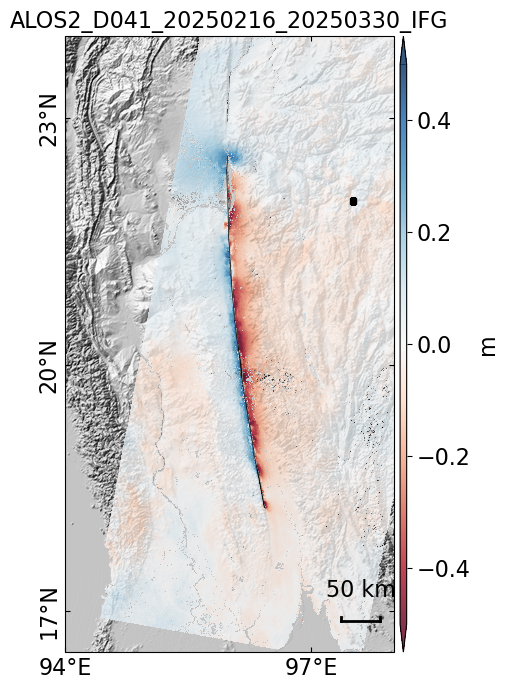

In [23]:
#unw_file = os.path.join(proj_dir, 'data_v2', dname, 'geo_filt_msk_ERA5_SET.unw')
unw_file = './geo/geo_filt_msk_ERA5_SET.unw'
out_file = f'./geo/{dname}_20{date1}_20{date2}_IFG.png'
cmd = f'{unw_file} phase --dem {dem_file} --dem-nocontour --shade-exag 0.05 --faultline {flt_file} '
cmd += f'-c RdBu -u m -v -0.5 0.5 --lalo-label --lalo-step 3 --ylabel-rot 90 --cbar-nbins 5 '
cmd += f'--scalebar 0.12 0.90 0.05 --title {dname}_20{date1}_20{date2}_IFG --ref-size 4 --math reverse --dpi 600 '
cmd += f'-o {out_file} '
view.main(cmd.split())

view.py ./geo/ion_msk.geo band1 --title ionosphere --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05
initiate cartopy map projection: PlateCarree
Un-scalable display unit: radian


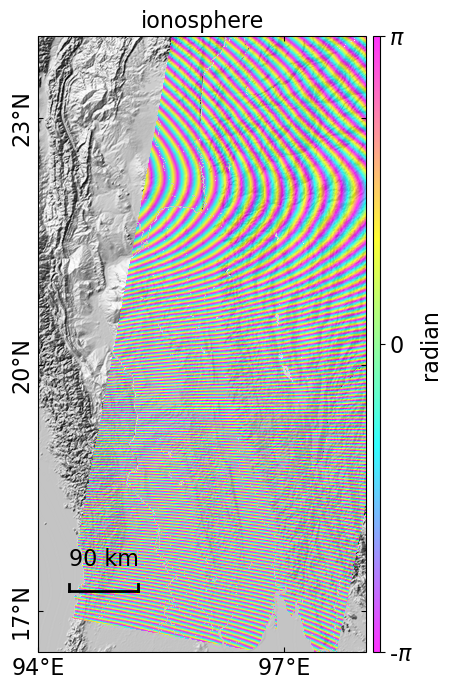

view.py ./geo/ERA5.h5 250330 --ref-date 250216 --title troposphere --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05
initiate cartopy map projection: PlateCarree


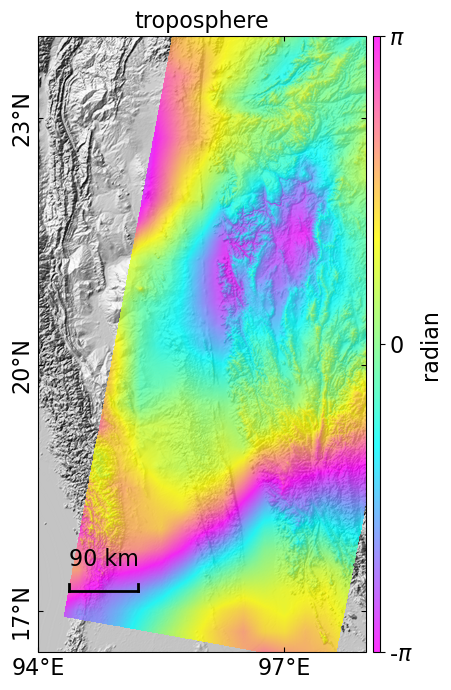

view.py ./geo/SET.h5 250330 --ref-date 250216 --dem /penguin/eedy/25EQ_myanmar/DEM/elevation_mli.dem -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05 --title solid Earth tides
initiate cartopy map projection: PlateCarree


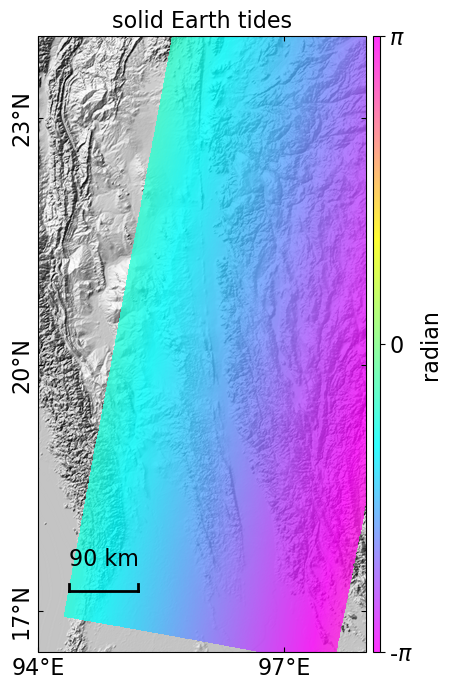

In [25]:
opt = f'--dem {dem_file} -c cmy -u radian --wrap --lalo-label --lalo-step 3 --ylabel-rot 90 --noreference --noverbose --save --dem-nocontour --shade-exag 0.05'
view.main(f'./geo/ion_msk.geo band1 --title ionosphere {opt} '.split())
view.main(f'./geo/ERA5.h5 {date2} --ref-date {date1} --title troposphere {opt} '.split())
view.main(f'./geo/SET.h5 {date2} --ref-date {date1} {opt} '.split() + ['--title', 'solid Earth tides'])